In [3]:

import numpy as np 
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)


import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


1| HAR là gì?

Human Activity Recognition (HAR) – hay còn gọi là nhận dạng hoạt động của con người – là một lĩnh vực nghiên cứu rộng, tập trung vào việc xác định chuyển động hoặc hành động cụ thể của một người dựa trên dữ liệu cảm biến.
Các chuyển động này thường là những hoạt động phổ biến trong đời sống hàng ngày, như đi bộ, nói chuyện, đứng, hoặc ngồi.
*Tại sao HAR lại quan trọng?

Nhận dạng hoạt động của con người đóng vai trò rất quan trọng trong việc hiểu và mô phỏng tương tác giữa người với người, cũng như trong các mối quan hệ xã hội. Vì HAR cung cấp thông tin về danh tính, tính cách và trạng thái tâm lý của một người – những yếu tố khó trích xuất – nên nó trở thành một thách thức lớn trong nghiên cứu. Khả năng của con người trong việc nhận biết hành động của người khác là một trong những chủ đề trọng tâm của các lĩnh vực thị giác máy tính (computer vision) và học máy (machine learning).
Nhờ các nghiên cứu trong lĩnh vực này, nhiều ứng dụng thực tế đã ra đời, bao gồm:

Hệ thống giám sát bằng video,

Giao tiếp người–máy (human-computer interaction),

Robot mô phỏng hành vi con người,

Và các hệ thống nhận dạng đa hoạt động phục vụ phân tích hành vi.

In [ ]:
!pip install seaborn

## 2| Importing thư viện

In [ ]:
import os
import glob
import random
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from PIL import Image
from torchvision import transforms
import torch
import torch.nn as nn

from torchvision import models
from sklearn.model_selection import train_test_split
import seaborn as sns
import matplotlib.image as img
import matplotlib.pyplot as plt
from torch.utils.data import TensorDataset, DataLoader, Subset
import joblib

# 3| Tải dữ liệu
Dữ liệu được lấy từ nguồn https://www.kaggle.com/code/kirollosashraf/human-action-recognition-har.

Là các ảnh tĩnh có số lượng ảnh vừa phải, chứa 15 lớp hoạt động của con người ( 15 activity classes): calling, clapping, cycling, dancing, drinking, eating, fighting, hugging, laughing, listening_to_music, running, sitting, sleeping, texting, using_laptop.

Có 12 600 ảnh cho huấn luyện-train- và 5400 ảnh cho kiểm trả-test.
Mỗi ảnh là một người.



In [5]:
# file training_set.csv(12600) chứa 2 cột 1 là tên file ảnh, 2 là nhãn -classify-
train_data = pd.read_csv("../input/human-action-recognition-har-dataset/Human Action Recognition/Training_set.csv")

In [6]:
# folder train chứa ảnh cho huấn luyện 
train_fol = glob.glob("../input/human-action-recognition-har-dataset/Human Action Recognition/train/*") 

In [7]:
train_data

,filename,label
0,Image_1.jpg,sitting
1,Image_2.jpg,using_laptop
2,Image_3.jpg,hugging
3,Image_4.jpg,sleeping
4,Image_5.jpg,using_laptop
...,...,...
12595,Image_12596.jpg,sitting
12596,Image_12597.jpg,clapping
12597,Image_12598.jpg,sitting
12598,Image_12599.jpg,dancing


Qua việc đếm số lượng => dataset này cân bằng giữa các lớp

In [7]:
train_data.label.value_counts()

label
sitting               840
using_laptop          840
hugging               840
sleeping              840
drinking              840
clapping              840
dancing               840
cycling               840
calling               840
laughing              840
eating                840
fighting              840
listening_to_music    840
running               840
texting               840
Name: count, dtype: int64

In [ ]:
!pip install plotly


In [ ]:
import plotly.express as px
HAR = train_data.label.value_counts()
fig = px.pie(train_data, values=HAR.values, names=HAR.index, title='Distribution of Human Activity')
fig.show()

In [9]:
# tên ảnh
filename = train_data['filename']
# lable hoạt động
situation = train_data['label']

In [10]:
filename

0            Image_1.jpg
1            Image_2.jpg
2            Image_3.jpg
3            Image_4.jpg
4            Image_5.jpg
              ...       
12595    Image_12596.jpg
12596    Image_12597.jpg
12597    Image_12598.jpg
12598    Image_12599.jpg
12599    Image_12600.jpg
Name: filename, Length: 12600, dtype: object

# 4| Xây dựng hàm để hiện thị ảnh ngẫu nhiên

In [11]:
def displaying_random_images():
    num = random.randint(1,10000)
    imgg = "Image_{}.jpg".format(num)
    train = "../input/human-action-recognition-har-dataset/Human Action Recognition/train/"
    if os.path.exists(train+imgg):
        testImage = img.imread(train+imgg)
        plt.imshow(testImage)
        plt.title("{}".format(train_data.loc[train_data['filename'] == "{}".format(imgg), 'label'].item()))

    else:
        #print(train+img)
        print("File Path not found \nSkipping the file!!")

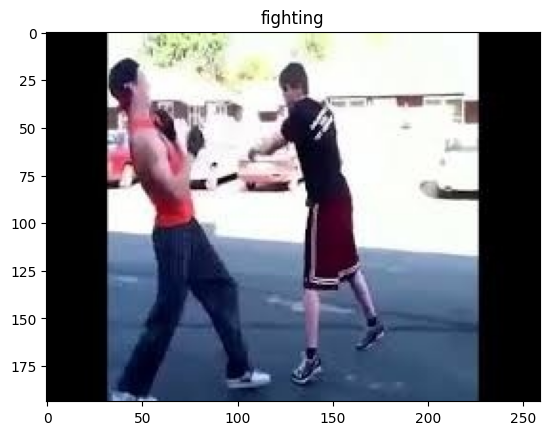

In [12]:
displaying_random_images()

# 5. tiền xử lí dữ liệu

Resize kích thước ảnh về một kích thước (160*160)

ColorJitter:  Tăng độ đa dạng dữ liệu — mô phỏng điều kiện ánh sáng, màu sắc khác nhau.

Horizontal Flip: Giúp mô hình học được tính “bất biến theo hướng” (orientation invariance) — ví dụ người đi trái hay đi phải đều là “đi bộ”.

Normalize: Chuẩn hóa phân phối pixel để mô hình học ổn định hơn bằng cách trừ đi giá trị trung bình và chia cho độ lệch chuẩn của từng kênh màu, giúp dữ liệu đầu vào có trung bình ≈ 0 và độ lệch chuẩn ≈ 1, giúp mô hình học ổn định hơn.”.

In [13]:
base_transform = transforms.Compose([
    # Resize: Chuẩn hóa kích thước đầu vào
    transforms.Resize((160, 160)),
    #  ColorJitter: Tăng đa dạng ánh sáng, độ tương phản, bão hòa
    transforms.ColorJitter(
        brightness=0.2,   # ±20% độ sáng
        contrast=0.2,     # ±20% độ tương phản
        saturation=0.2     # ±20% độ bão hòa
    ),
    #  Chuyển sang tensor, giá trị pixel ∈ [0,1]
    transforms.ToTensor(),
    #  Normalize: Chuẩn hóa phân phối pixel
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

Load ảnh vào 2 mảng sử dụng biến đổi ảnh gốc thành 2 ảnh : ảnh gốc và ảnh lật ngang

In [14]:
img_data = []
img_label = []
flip_transform = transforms.RandomHorizontalFlip(p=1.0)
for i in (range(len(train_fol)-1)):
    path = '../input/human-action-recognition-har-dataset/Human Action Recognition/train/' + filename[i]
    temp_img = Image.open(path).convert('RGB')
    # Thực hiện xử lí ảnh
    img_original = base_transform(temp_img)
    # Lưu ảnh gốc.
    img_data.append(img_original)
    img_label.append(situation[i])
    # Lật ảnh và lưu trữ
    img_flip = flip_transform(temp_img)
    img_data.append(base_transform(img_flip))
    img_label.append(situation[i])
    

Chuyển đổi label từ kí tự sang số

In [15]:
label_encoder = LabelEncoder()
img_label_encoded = label_encoder.fit_transform(img_label)

# Xem thử ánh xạ
print("Classes mapping:")
for cls, idx in zip(label_encoder.classes_, range(len(label_encoder.classes_))):
    print(f"{idx}: {cls}")
# Lưu trữ để sử dụng truyển ngược lại hành động khi dự đoán
joblib.dump(label_encoder, "label_encoder.pkl")

Classes mapping:
0: calling
1: clapping
2: cycling
3: dancing
4: drinking
5: eating
6: fighting
7: hugging
8: laughing
9: listening_to_music
10: running
11: sitting
12: sleeping
13: texting
14: using_laptop


['label_encoder.pkl']

In [ ]:
img = img_data[1]
label = img_label[1]

plt.imshow(F.to_pil_image(img))
plt.title(f"Label: {label}")
plt.axis("off")
plt.show()

# 6| Xây dựng kiến trúc model huấn luyện và đánh giá

Sử dụng model ResNet để huấn luyện. Model này đã được huấn luyện trên ImageNet.

ResNet là một kiến trúc mạng nơ-ron tích chập(CNN) được giới thiệu năm 2015 bởi nhóm nghiên cứu của Microsoft Reseach(He et al) và đạt giải vô địch ImageNet 2015 với độ chính xác vượt trội. Xem chi tiết tại paper : "Deep Residual Learning for Image Recognition" – Kaiming He et al., 2015

Sẽ finetune lại ResNet để phù hợp với dataset sử dụng

Tạo Dataset

In [16]:
num_classes = len(label_encoder.classes_)
# Gộp lại thành Tensor (stack các ảnh lại)
X_train = torch.stack(img_data)
y_train = torch.tensor(img_label_encoded, dtype=torch.long)
# Tạo Dataset
dataset = TensorDataset(X_train, y_train)



In [17]:
# Chia dữ liệu 80-20
train_idx, val_idx = train_test_split(list(range(len(dataset))), test_size=0.2, random_state=42)
train_loader = DataLoader(Subset(dataset, train_idx), batch_size=32, shuffle=True)
val_loader = DataLoader(Subset(dataset, val_idx), batch_size=32, shuffle=False)

Fine tune model 

In [24]:
# --- Cấu hình model ---
import torch.optim as optim
model = models.resnet18(weights='IMAGENET1K_V1')
for param in model.parameters():
    param.requires_grad = False

model.fc = nn.Sequential(
    nn.Linear(model.fc.in_features, 256),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(256, num_classes)
)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

criterion = nn.CrossEntropyLoss()
#Weight decay là một kỹ thuật phạt (penalty) lên các trọng số (weights) lớn trong mô hình.
# Khi trọng số càng lớn → mô hình càng dễ fit quá mức dữ liệu train → giảm khả năng khái quát (generalization).
#Vì vậy, weight decay sẽ ép trọng số nhỏ lại trong quá trình huấn luyện.
optimizer = optim.Adam(model.fc.parameters(), lr=1e-3)
# Giảm LR khi val acc không cải thiện 3 epoch
# mode =max thể hiện cho accuracy, patience: số epoch chờ, factor: hệ số giảm lr ở đây 0.2 là 20%
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', patience=6, factor=0.2, verbose=True
)

🚀 Bắt đầu huấn luyện 128 epochs...


📊 Epoch [1/128] | Loss: 1.6846 | Val Acc: 56.65% | LR: 0.00100 | ⏱️ 10.3s


📊 Epoch [2/128] | Loss: 1.4066 | Val Acc: 58.87% | LR: 0.00100 | ⏱️ 10.2s


📊 Epoch [3/128] | Loss: 1.3288 | Val Acc: 59.05% | LR: 0.00100 | ⏱️ 10.2s


📊 Epoch [4/128] | Loss: 1.2765 | Val Acc: 60.40% | LR: 0.00100 | ⏱️ 10.3s


📊 Epoch [5/128] | Loss: 1.2208 | Val Acc: 60.30% | LR: 0.00100 | ⏱️ 10.2s


📊 Epoch [6/128] | Loss: 1.1970 | Val Acc: 62.68% | LR: 0.00100 | ⏱️ 10.2s


📊 Epoch [7/128] | Loss: 1.1512 | Val Acc: 62.66% | LR: 0.00100 | ⏱️ 10.3s


📊 Epoch [8/128] | Loss: 1.1114 | Val Acc: 63.87% | LR: 0.00100 | ⏱️ 10.2s


📊 Epoch [9/128] | Loss: 1.0930 | Val Acc: 63.89% | LR: 0.00100 | ⏱️ 10.3s


📊 Epoch [10/128] | Loss: 1.0580 | Val Acc: 64.17% | LR: 0.00100 | ⏱️ 10.3s


📊 Epoch [11/128] | Loss: 1.0254 | Val Acc: 64.46% | LR: 0.00100 | ⏱️ 10.3s


📊 Epoch [12/128] | Loss: 1.0083 | Val Acc: 63.47% | LR: 0.00100 | ⏱️ 10.3s


📊 Epoch [13/128] | Loss: 0.9907 | Val Acc: 64.90

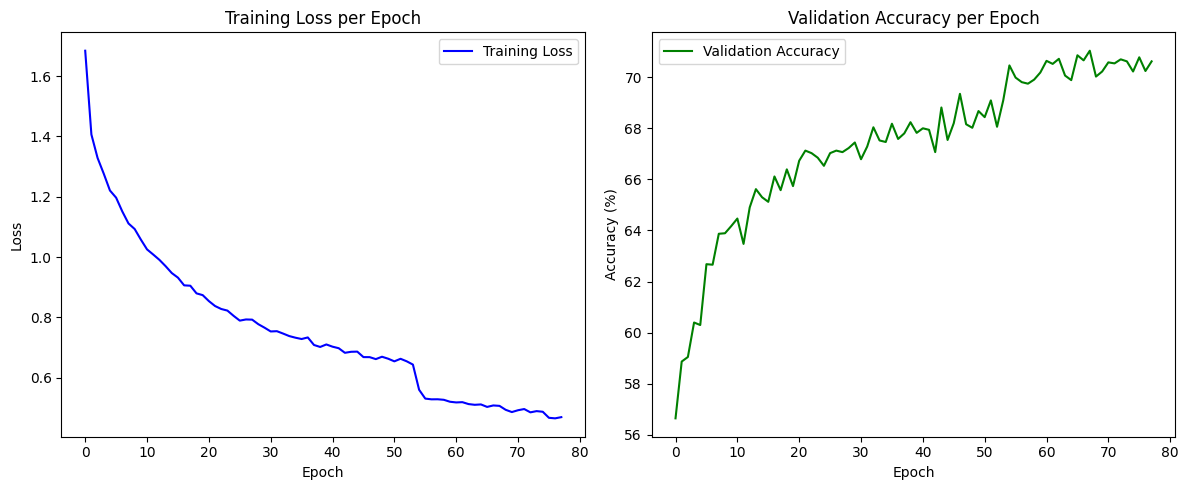

In [25]:
import time
num_epochs = 128
best_acc = 0.0
early_stop_patience = 10  # Dừng nếu không cải thiện sau 10 epoch
epochs_no_improve = 0

train_losses = []
val_accuracies = []

print(f"🚀 Bắt đầu huấn luyện {num_epochs} epochs...\n", flush=True)
start_time = time.time()

# ----------------------------
# 🔁 Training Loop
# ----------------------------
for epoch in range(num_epochs):
    epoch_start = time.time()
    model.train()
    running_loss = 0.0

    for i, (images, labels) in enumerate(train_loader):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)
    train_losses.append(avg_loss)

    # --- Validation ---
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    acc = 100 * correct / total
    val_accuracies.append(acc)

    # Giảm LR nếu acc không cải thiện
    scheduler.step(acc)

    print(f"\n📊 Epoch [{epoch+1}/{num_epochs}] | "
          f"Loss: {avg_loss:.4f} | Val Acc: {acc:.2f}% | "
          f"LR: {optimizer.param_groups[0]['lr']:.5f} | "
          f"⏱️ {time.time() - epoch_start:.1f}s\n", flush=True)

    # --- Lưu model tốt nhất ---
    if acc > best_acc + 1e-4:
        best_acc = acc
        torch.save(model.state_dict(), "best_model_lr_01.pth")
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1

    # --- Early stopping ---
    if epochs_no_improve >= early_stop_patience:
        print(f"🛑 Early stopping sau {epoch+1} epochs (không cải thiện {early_stop_patience} lần liên tiếp).")
        break

print(f"\n✅ Huấn luyện xong! Best Validation Accuracy: {best_acc:.2f}% | "
      f"Total time: {time.time() - start_time:.1f}s")

# ----------------------------
# 📈 Vẽ biểu đồ
# ----------------------------
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(train_losses, 'b-', label='Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss per Epoch')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(val_accuracies, 'g-', label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Validation Accuracy per Epoch')
plt.legend()

plt.tight_layout()
plt.show()